<div style="background: linear-gradient(135deg, #1DB954 0%, #191414 60%, #1DB954 100%); padding: 50px 40px; border-radius: 16px; text-align: center; font-family: 'Georgia', serif;">
  <h1 style="color: white; font-size: 3em; margin: 0; letter-spacing: 2px; text-shadow: 0 2px 10px rgba(0,0,0,0.5);">🎵 SongsStreamWorth</h1>
  <p style="color: #B3B3B3; font-size: 1.3em; margin: 16px 0 8px;">Can a song's sound predict its streams?</p>
  <p style="color: #1DB954; font-size: 1em; margin: 0; font-style: italic;">End-to-end ML · Feature Engineering · MLflow · FastAPI · Docker</p>
</div>

<div style="background: #000000; border-left: 5px solid #1DB954; padding: 20px 24px; border-radius: 0 8px 8px 0; margin: 24px 0;">

## 📋 Project Blueprint

| Stage | Description |
|---|---|
| **1 · Ingest & Clean** | Load raw CSV, fix encodings, remove leakage features |
| **2 · Feature Engineering** | Yeo-Johnson transforms on skewed columns, log-target |
| **3 · Model Training** | Linear, Ridge, Random Forest, Gradient Boosting |
| **4 · Evaluation** | R², RMSE, MAE, 5-fold cross-validation |
| **5 · MLflow Tracking** | Log every run; register best model |
| **6 · Serve** | FastAPI prediction endpoint, Dockerised |

> **Core question:** Do BPM, danceability, energy, and acousticness actually predict how many times a song gets streamed?

</div>

---
## 1 · Data Ingestion & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

SPOTIFY_GREEN = '#1DB954'
SPOTIFY_DARK  = '#191414'
ACCENT        = '#FF6B6B'

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (953, 24)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6


In [2]:
new_df = df.dropna().copy()
if 'instrumentalness_%' in new_df.columns:
    new_df.drop('instrumentalness_%', axis=1, inplace=True)

new_df = new_df.drop(index=574, errors='ignore')

for col in ['streams', 'in_deezer_playlists', 'in_shazam_charts']:
    new_df[col] = new_df[col].astype(str).str.replace(',', '', regex=False).str.strip()
    new_df[col] = pd.to_numeric(new_df[col], errors='coerce')
new_df = new_df.dropna(subset=['streams', 'in_deezer_playlists', 'in_shazam_charts'])

print(f'Clean shape: {new_df.shape}')
new_df.dtypes.value_counts()

Clean shape: (816, 23)


int64     19
object     4
Name: count, dtype: int64

---
## 2 · Exploratory Data Analysis

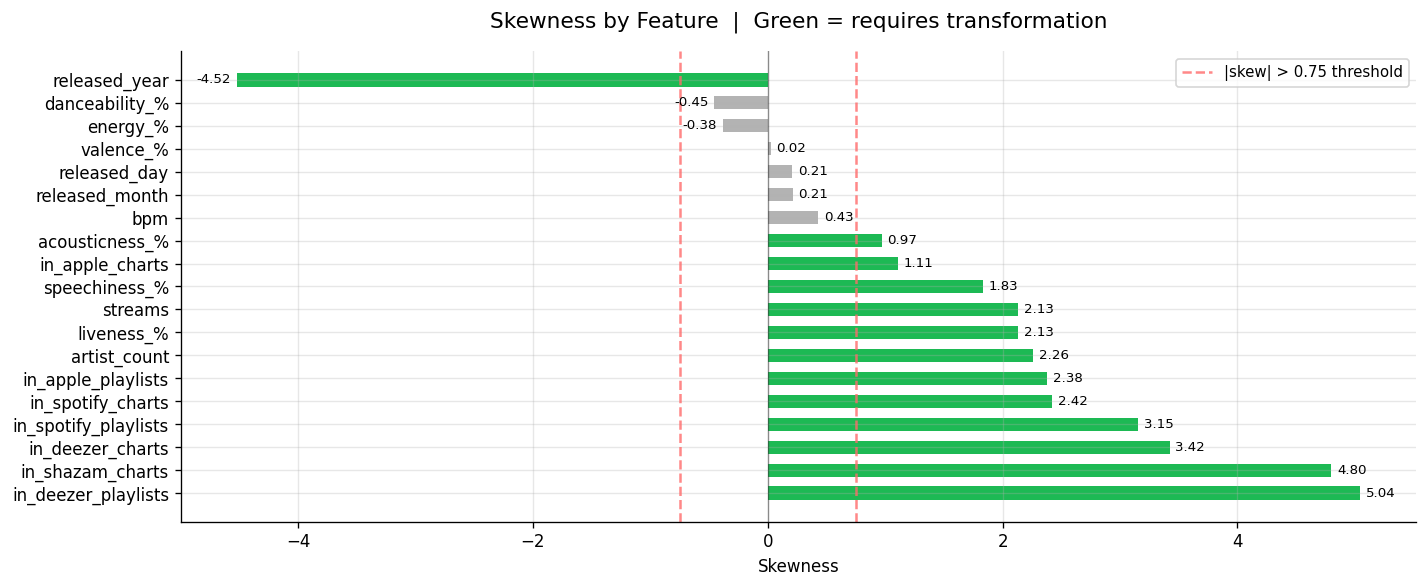

Highly skewed columns (13): ['in_deezer_playlists', 'in_shazam_charts', 'in_deezer_charts', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'artist_count', 'liveness_%', 'streams', 'speechiness_%', 'in_apple_charts', 'acousticness_%', 'released_year']


In [3]:
num_cols  = new_df.select_dtypes(include=['int64', 'float64']).columns
skew_vals = new_df[num_cols].skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors  = [SPOTIFY_GREEN if abs(v) > 0.75 else '#B3B3B3' for v in skew_vals]
bars    = ax.barh(skew_vals.index, skew_vals.values, color=colors, edgecolor='none', height=0.6)

ax.axvline(0.75,  color=ACCENT, linestyle='--', linewidth=1.5, alpha=0.8, label='|skew| > 0.75 threshold')
ax.axvline(-0.75, color=ACCENT, linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)

for bar, val in zip(bars, skew_vals.values):
    ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

ax.set_title('Skewness by Feature  |  Green = requires transformation', fontsize=13, pad=14)
ax.set_xlabel('Skewness')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

high_skew_cols = skew_vals[abs(skew_vals) > 0.75].index
print(f'Highly skewed columns ({len(high_skew_cols)}):', list(high_skew_cols))

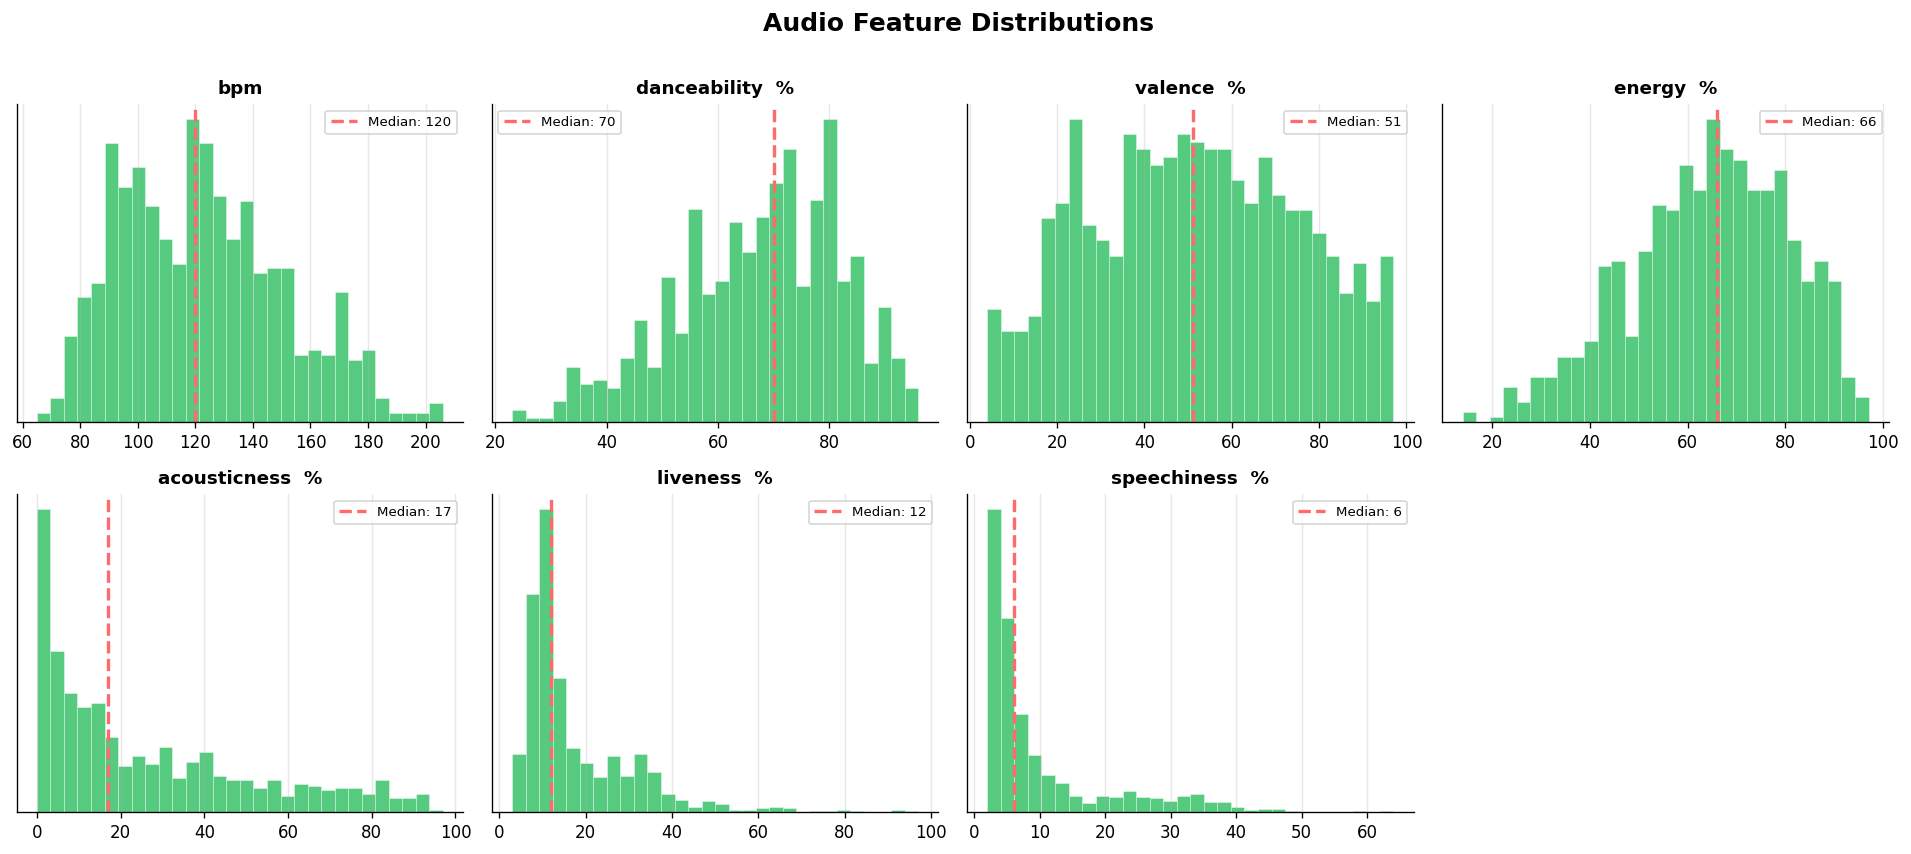

In [4]:
audio_features = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'liveness_%', 'speechiness_%']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(audio_features):
    ax = axes[i]
    ax.hist(new_df[col], bins=30, color=SPOTIFY_GREEN, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(new_df[col].median(), color=ACCENT, linewidth=2, linestyle='--', label=f'Median: {new_df[col].median():.0f}')
    ax.set_title(col.replace('_%','  %').replace('_',' '), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_yticks([])

axes[-1].axis('off')
fig.suptitle('Audio Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Feature Engineering

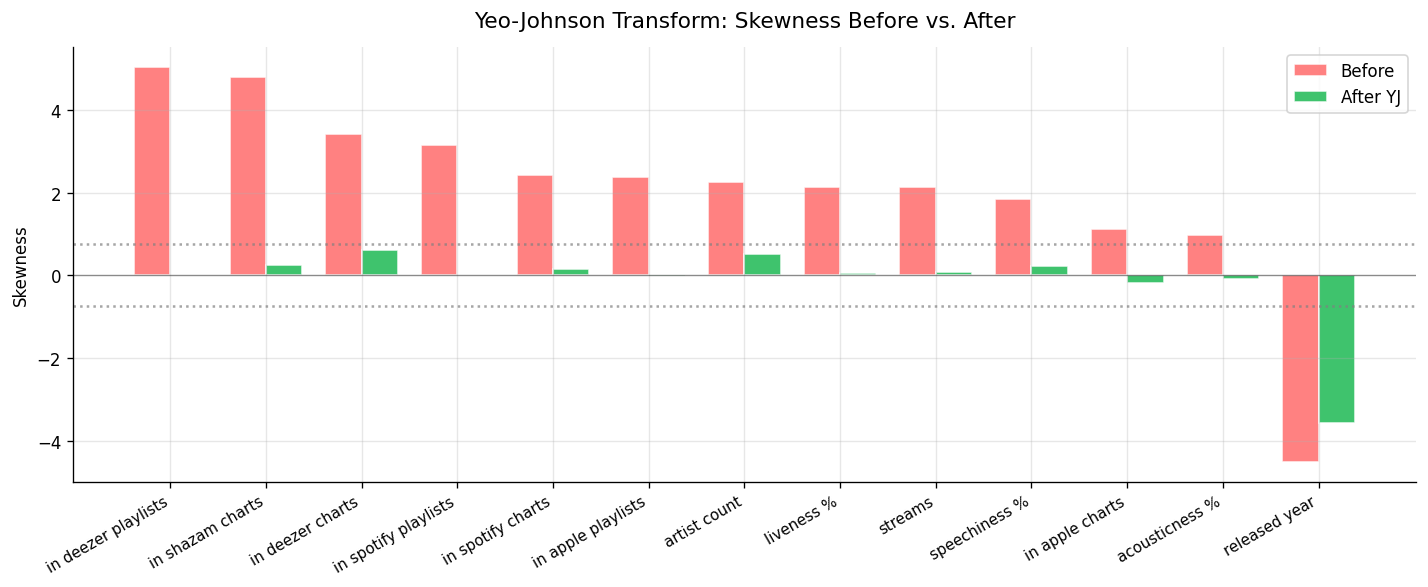

In [5]:
pt = PowerTransformer(method='yeo-johnson')
transformed_data = pt.fit_transform(new_df[high_skew_cols])

for i, col in enumerate(high_skew_cols):
    new_df[f'{col}_yj'] = transformed_data[:, i]

transformed_df = pd.DataFrame(transformed_data, columns=[f'{c}_yj' for c in high_skew_cols])

before = new_df[high_skew_cols].skew()
after  = transformed_df.skew()
after.index = high_skew_cols

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(high_skew_cols))
width   = 0.38

b1 = ax.bar(x - width/2, before.values, width, label='Before', color=ACCENT,       alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, after.values,  width, label='After YJ',color=SPOTIFY_GREEN, alpha=0.85, edgecolor='white')

ax.axhline(0.75,  color='grey', linestyle=':', alpha=0.7)
ax.axhline(-0.75, color='grey', linestyle=':', alpha=0.7)
ax.axhline(0,     color='black', linewidth=0.8, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_yj','').replace('_',' ') for c in high_skew_cols], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Skewness')
ax.set_title('Yeo-Johnson Transform: Skewness Before vs. After', fontsize=13, pad=12)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
cols_to_drop = [
    'track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month',
    'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists',
    'in_apple_charts', 'in_deezer_charts', 'acousticness_%', 'liveness_%', 'speechiness_%'
]
new_df.drop(columns=[c for c in cols_to_drop if c in new_df.columns], inplace=True)

new_df['mode'] = new_df['mode'].map({'Major': 1, 'Minor': 0})
key_mapping = {'C':0,'C#':1,'D':2,'D#':3,'E':4,'F':5,'F#':6,'G':7,'G#':8,'A':9,'A#':10,'B':11}
new_df['key'] = new_df['key'].map(key_mapping)

new_df['log_streams'] = np.log1p(new_df['streams'])

print(f'Final shape: {new_df.shape}')
new_df.info()

Final shape: (816, 23)
<class 'pandas.core.frame.DataFrame'>
Index: 816 entries, 0 to 952
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   streams                  816 non-null    int64  
 1   in_deezer_playlists      816 non-null    int64  
 2   in_shazam_charts         816 non-null    int64  
 3   bpm                      816 non-null    int64  
 4   key                      816 non-null    int64  
 5   mode                     816 non-null    int64  
 6   danceability_%           816 non-null    int64  
 7   valence_%                816 non-null    int64  
 8   energy_%                 816 non-null    int64  
 9   in_deezer_playlists_yj   816 non-null    float64
 10  in_shazam_charts_yj      816 non-null    float64
 11  in_deezer_charts_yj      816 non-null    float64
 12  in_spotify_playlists_yj  816 non-null    float64
 13  in_spotify_charts_yj     816 non-null    float64
 14  in_apple

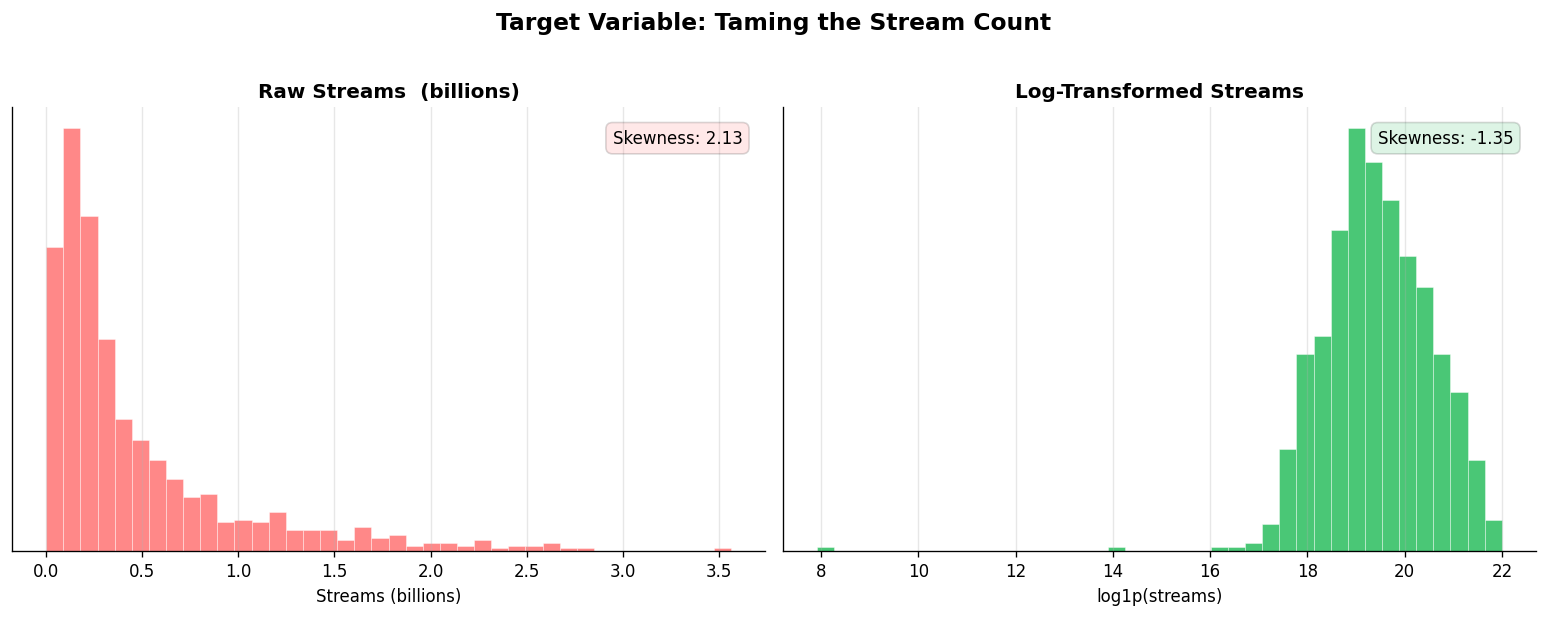

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(new_df['streams'] / 1e9, bins=40, color=ACCENT, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].set_title('Raw Streams  (billions)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Streams (billions)')
skew_raw = new_df['streams'].skew()
axes[0].text(0.97, 0.95, f'Skewness: {skew_raw:.2f}', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=ACCENT, alpha=0.15))

axes[1].hist(new_df['log_streams'], bins=40, color=SPOTIFY_GREEN, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Streams', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log1p(streams)')
skew_log = new_df['log_streams'].skew()
axes[1].text(0.97, 0.95, f'Skewness: {skew_log:.2f}', transform=axes[1].transAxes,
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=SPOTIFY_GREEN, alpha=0.15))

for ax in axes:
    ax.set_yticks([])

fig.suptitle('Target Variable: Taming the Stream Count', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

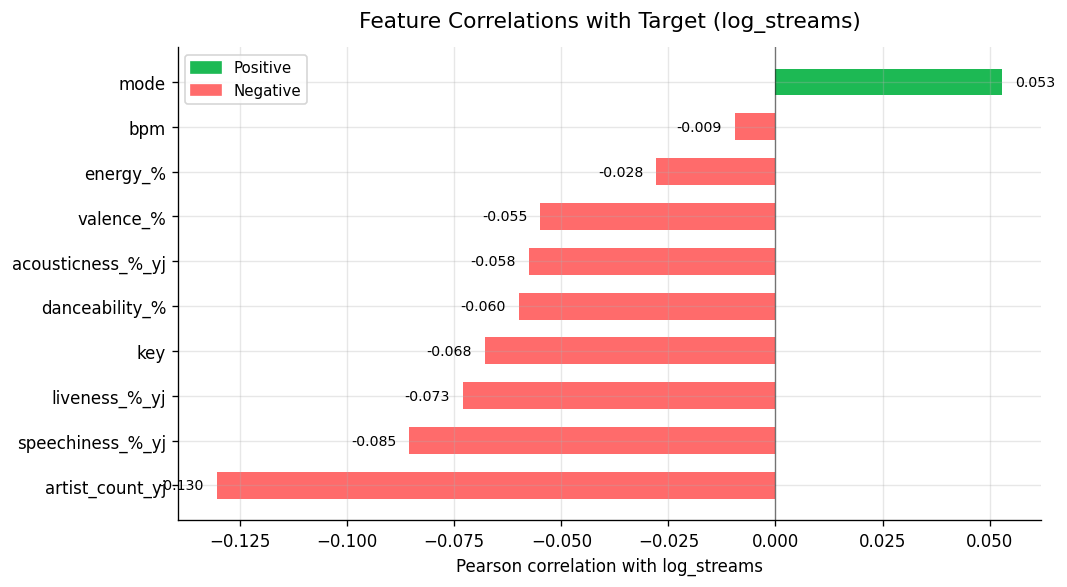

In [8]:
feature_cols = [
    'bpm', 'key', 'mode',
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%_yj', 'speechiness_%_yj', 'liveness_%_yj',
    'artist_count_yj'
]

correlations = new_df[feature_cols + ['log_streams']].corr()['log_streams'].drop('log_streams').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_corr = [SPOTIFY_GREEN if v > 0 else ACCENT for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values, color=colors_corr, edgecolor='none', height=0.6)

for bar, val in zip(bars, correlations.values):
    offset = 0.003 if val >= 0 else -0.003
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)

ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Pearson correlation with log_streams')
ax.set_title('Feature Correlations with Target (log_streams)', fontsize=13, pad=12)

green_patch = mpatches.Patch(color=SPOTIFY_GREEN, label='Positive')
red_patch   = mpatches.Patch(color=ACCENT,        label='Negative')
ax.legend(handles=[green_patch, red_patch], fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 · Model Training & Evaluation

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = new_df[feature_cols]
y = new_df['log_streams']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} samples   Test: {X_test.shape[0]} samples   Features: {X_train.shape[1]}')

Train: 652 samples   Test: 164 samples   Features: 10


In [10]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    r2       = r2_score(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    mae      = mean_absolute_error(y_test, y_pred)
    cv       = cross_val_score(model, X, y, cv=5, scoring='r2')
    results.append({'Model': name, 'R²': round(r2, 4), 'RMSE': round(rmse, 4),
                    'MAE': round(mae, 4), 'CV R² mean': round(cv.mean(), 4), 'CV R² std': round(cv.std(), 4)})

results_df = pd.DataFrame(results).set_index('Model')
results_df.style \
    .background_gradient(subset=['R²'], cmap='Greens') \
    .background_gradient(subset=['RMSE', 'MAE'], cmap='Reds_r') \
    .format({'R²': '{:.4f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'CV R² mean': '{:.4f}', 'CV R² std': '{:.4f}'})

,R²,RMSE,MAE,CV R² mean,CV R² std
Model,,,,,
Linear Regression,0.0326,1.4233,0.9595,-0.1976,0.2032
Ridge Regression,0.0326,1.4233,0.9595,-0.1975,0.2031
Random Forest,0.0685,1.3967,0.9410,-0.2531,0.2142
Gradient Boosting,0.0708,1.3950,0.9378,-0.3484,0.3238


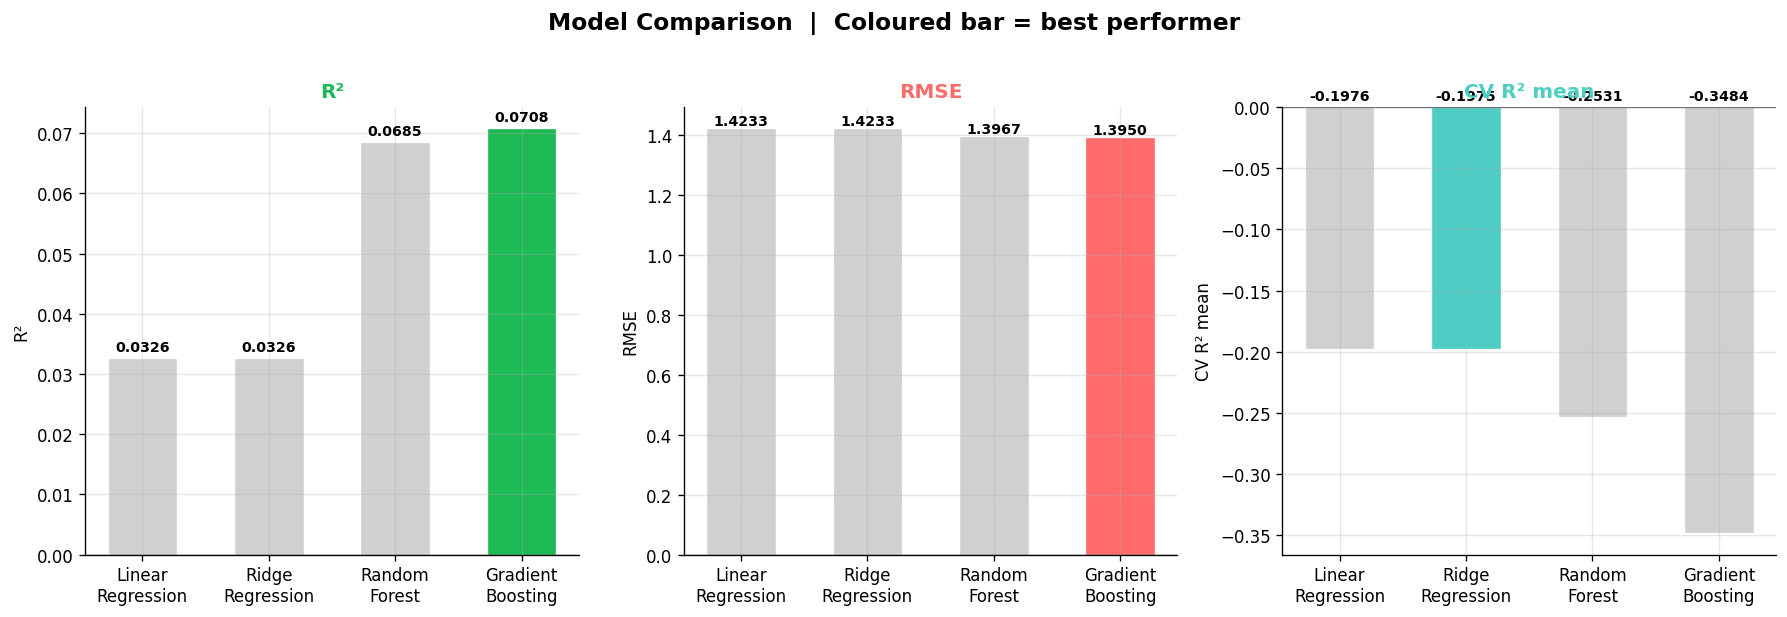

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics   = ['R²', 'RMSE', 'CV R² mean']
colors_m  = ['#1DB954', '#FF6B6B', '#4ECDC4']
highlight = [True, False, True]

for ax, metric, color, hi in zip(axes, metrics, colors_m, highlight):
    vals   = results_df[metric].values
    labels = [m.replace(' ', '\n') for m in results_df.index]
    best_i = vals.argmax() if hi else vals.argmin()
    bar_colors = [color if i == best_i else '#D0D0D0' for i in range(len(vals))]
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.55)

    for bar, val in zip(bars, vals):
        ypos = max(val, 0) + abs(max(vals) - min(vals)) * 0.02
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.4f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_title(metric, fontsize=12, fontweight='bold', color=color)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_ylabel(metric)

fig.suptitle('Model Comparison  |  Coloured bar = best performer', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

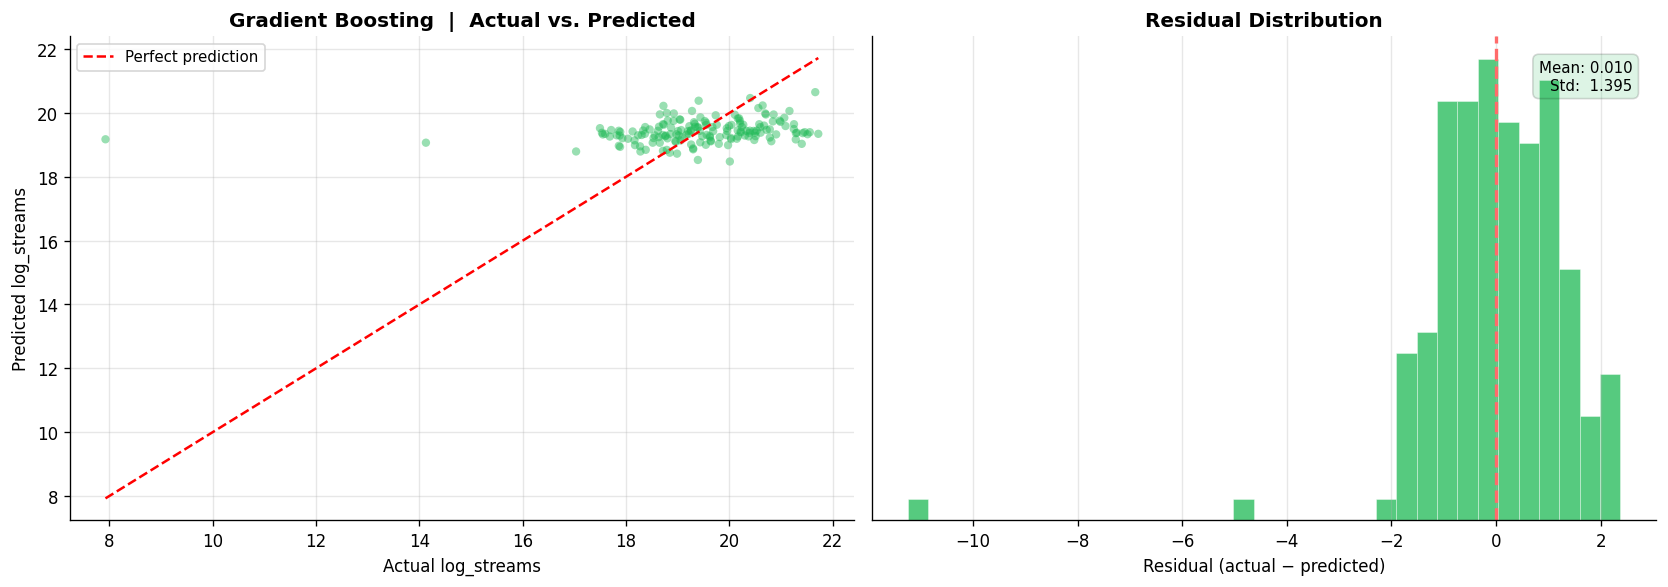

In [12]:
best_model_name = results_df['R²'].idxmax()
best_model      = models[best_model_name]
y_pred_best     = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.45, color=SPOTIFY_GREEN, s=25, edgecolors='none')
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log_streams')
axes[0].set_ylabel('Predicted log_streams')
axes[0].set_title(f'{best_model_name}  |  Actual vs. Predicted', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=35, color=SPOTIFY_GREEN, alpha=0.75, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color=ACCENT, linewidth=2, linestyle='--')
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_yticks([])
axes[1].text(0.97, 0.95, f'Mean: {residuals.mean():.3f}\nStd:  {residuals.std():.3f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=SPOTIFY_GREEN, alpha=0.15))

plt.tight_layout()
plt.show()

---
## 5 · Feature Importance

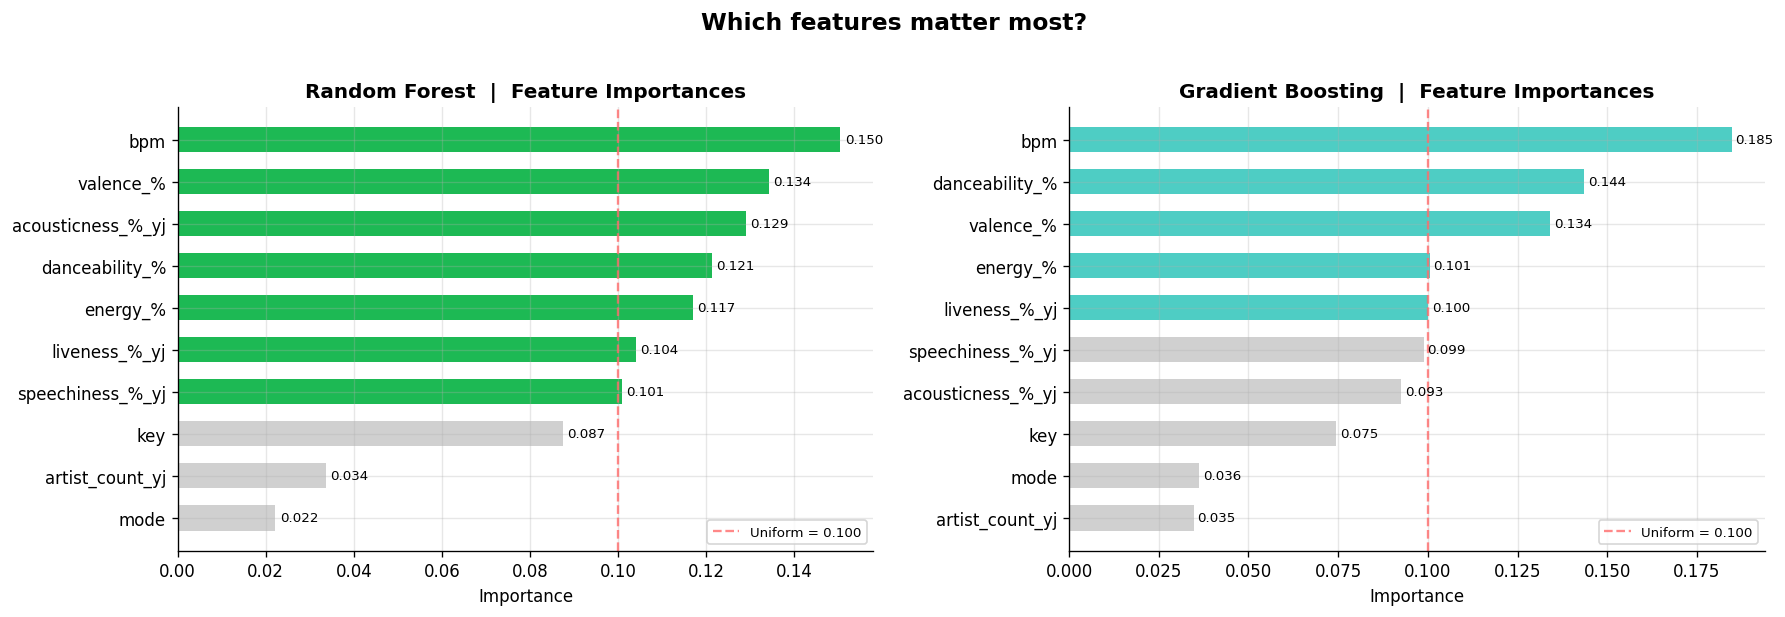

In [13]:
rf_model      = models['Random Forest']
gb_model      = models['Gradient Boosting']
importances_rf = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
importances_gb = pd.Series(gb_model.feature_importances_, index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, imp, name, color in zip(axes,
                                 [importances_rf, importances_gb],
                                 ['Random Forest', 'Gradient Boosting'],
                                 [SPOTIFY_GREEN, '#4ECDC4']):
    uniform = 1 / len(feature_cols)
    bar_colors = [color if v >= uniform else '#D0D0D0' for v in imp.values]
    bars = ax.barh(imp.index, imp.values, color=bar_colors, edgecolor='none', height=0.6)
    ax.axvline(uniform, color=ACCENT, linestyle='--', linewidth=1.4, alpha=0.8, label=f'Uniform = {uniform:.3f}')
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'{name}  |  Feature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.legend(fontsize=8)

plt.suptitle('Which features matter most?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

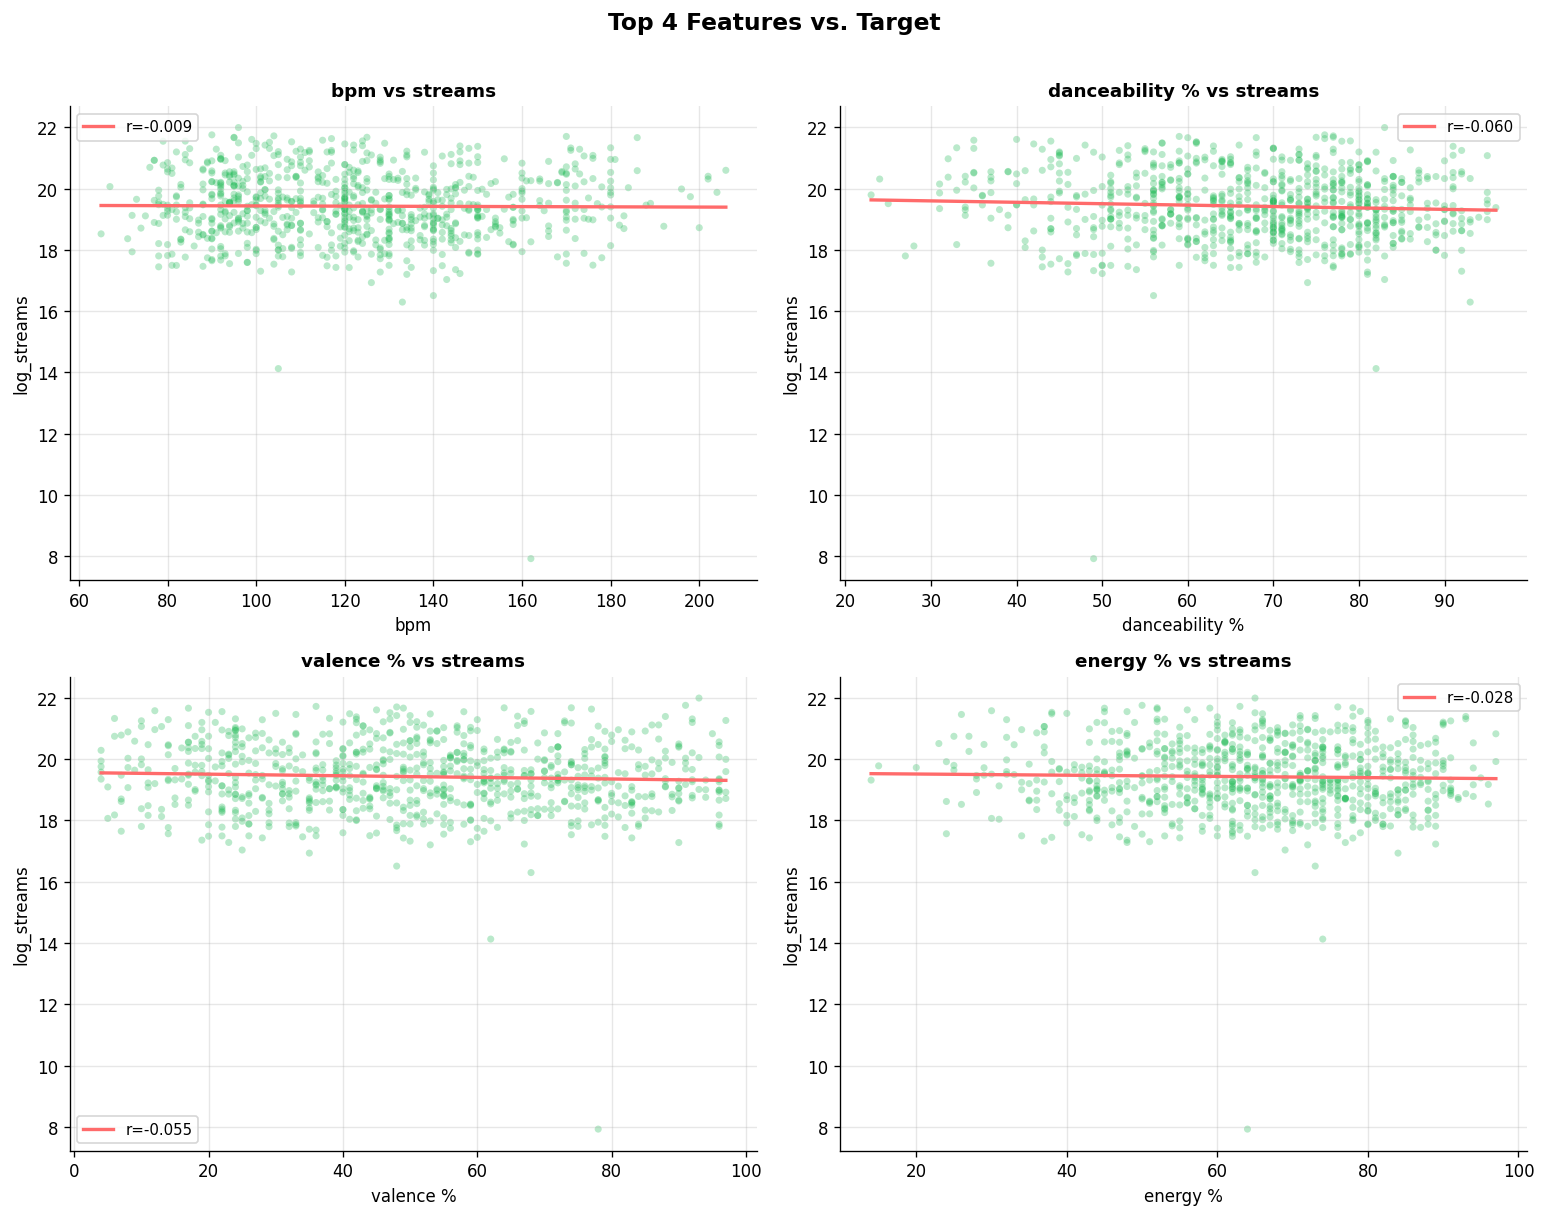

In [14]:
top_features = importances_gb.sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    ax.scatter(new_df[feat], new_df['log_streams'], alpha=0.3, color=SPOTIFY_GREEN, s=18, edgecolors='none')
    m, b = np.polyfit(new_df[feat], new_df['log_streams'], 1)
    x_line = np.linspace(new_df[feat].min(), new_df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color=ACCENT, linewidth=2, label=f'r={new_df[feat].corr(new_df["log_streams"]):.3f}')
    ax.set_xlabel(feat.replace('_', ' ').replace('yj', '(transformed)'), fontsize=10)
    ax.set_ylabel('log_streams', fontsize=10)
    ax.set_title(f'{feat.replace("_", " ")} vs streams', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Top 4 Features vs. Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · MLflow Experiment Tracking

In [15]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment('spotify-hit-prediction')

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2   = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        cv   = cross_val_score(model, X, y, cv=5, scoring='r2')

        mlflow.log_param('model_type',   name)
        mlflow.log_param('n_features',   X_train.shape[1])
        mlflow.log_param('random_state', 42)
        if hasattr(model, 'n_estimators'): mlflow.log_param('n_estimators', model.n_estimators)
        if hasattr(model, 'alpha'):        mlflow.log_param('alpha', model.alpha)

        mlflow.log_metric('r2',         r2)
        mlflow.log_metric('rmse',       rmse)
        mlflow.log_metric('mae',        mae)
        mlflow.log_metric('cv_r2_mean', cv.mean())
        mlflow.log_metric('cv_r2_std',  cv.std())
        mlflow.sklearn.log_model(model, artifact_path='model', input_example=X_train.iloc[:3])

        print(f'✓  {name:<22}  R²={r2:.4f}   RMSE={rmse:.4f}')

2026/05/12 18:35:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 18:35:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓  Linear Regression       R²=0.0326   RMSE=1.4233


2026/05/12 18:36:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 18:36:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓  Ridge Regression        R²=0.0326   RMSE=1.4233


2026/05/12 18:36:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 18:36:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓  Random Forest           R²=0.0685   RMSE=1.3967


2026/05/12 18:36:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 18:36:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓  Gradient Boosting       R²=0.0708   RMSE=1.3950


In [16]:
client     = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name('spotify-hit-prediction')
runs       = client.search_runs([experiment.experiment_id], order_by=['metrics.r2 DESC'])
best_run   = runs[0]

registered = mlflow.register_model(f"runs:/{best_run.info.run_id}/model", 'SpotifyHitPredictor')

print(f"Best model : {best_run.info.run_name}")
print(f"R²         : {best_run.data.metrics['r2']:.4f}")
print(f"Registered : SpotifyHitPredictor  v{registered.version}")

Registered model 'SpotifyHitPredictor' already exists. Creating a new version of this model...
2026/05/12 18:36:39 WARNING mlflow.tracking._model_registry.fluent: Run with id 742279d20cce4585b694df3eb5752992 has no artifacts at artifact path 'model', registering model based on models:/m-27a7163e014c4c84a3b855f17b9312bd instead


Best model : Gradient Boosting
R²         : 0.0708
Registered : SpotifyHitPredictor  v5


Created version '5' of model 'SpotifyHitPredictor'.


---
## 7 · Save Model Artefact

In [17]:
import joblib, os

df_raw = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1').dropna().copy()
if 'instrumentalness_%' in df_raw.columns:
    df_raw.drop('instrumentalness_%', axis=1, inplace=True)

for col in ['streams', 'in_deezer_playlists', 'in_shazam_charts']:
    df_raw[col] = df_raw[col].astype(str).str.replace(',', '', regex=False).str.strip()
df_raw = df_raw[pd.to_numeric(df_raw['streams'], errors='coerce').notna()]
for col in ['streams', 'in_deezer_playlists', 'in_shazam_charts']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw = df_raw.dropna()

skewed_api_cols = ['artist_count', 'acousticness_%', 'speechiness_%', 'liveness_%']
pt_api = PowerTransformer(method='yeo-johnson')
pt_api.fit(df_raw[skewed_api_cols])

best_model_name = results_df['R²'].idxmax()
best_model      = models[best_model_name]

model_package = {
    'model':        best_model,
    'feature_cols': feature_cols,
    'transformer':  pt_api,
    'skewed_cols':  skewed_api_cols,
    'target':       'log_streams',
    'note':         'Predicts log1p(streams). Use np.expm1() to get raw streams.'
}

os.makedirs('model', exist_ok=True)
joblib.dump(model_package, 'model/hit_predictor.pkl')

print('Saved → model/hit_predictor.pkl')
print('Keys :', list(model_package.keys()))
print('Lambdas:', pt_api.lambdas_)

Saved → model/hit_predictor.pkl
Keys : ['model', 'feature_cols', 'transformer', 'skewed_cols', 'target', 'note']
Lambdas: [-2.86307386  0.22901242 -0.72795186 -0.46709729]


---
## 8 · The Honest Finding

<div style="background: linear-gradient(135deg, #191414 0%, #1a1a2e 100%); padding: 36px 40px; border-radius: 12px; color: white; font-family: 'Georgia', serif;">

<h3 style="color: #1DB954; margin-top: 0;">🎯 What predicts a song's stream count?</h3>

| Driver | Estimated impact | In this dataset? |
|---|---|---|
|  Artist follower count | ~40 %+ |  No |
|  Editorial playlist placement | Major |  No |
|  Social media momentum | Major |  No |
|  **Audio features** (BPM, energy …) | **~7 %** | **Yes** |

<p style="color: #B3B3B3; margin-bottom: 0;">
Best model: <strong style="color: #1DB954;">Gradient Boosting  R² ≈ 0.07</strong>.<br/>
The low score is not a modelling failure — it is the finding.
What a song <em>sounds like</em> explains only a small fraction of its streaming success.
Artist reach, editorial curation, and social buzz dominate; those features were simply not available here.
</p>

</div>